# Uncertainty Quantification

**Lecture 8. Computational Data Analysis with Python**

*Knowing what you do not know*

---

This notebook is self-contained. It covers:

1. **Why uncertainty matters**: for communication, decisions, and diagnostics
2. **Frequentist vs. Bayesian probability**: two interpretations, one set of axioms
3. **Confidence intervals**: the correct interpretation, mechanics, prediction vs. CI
4. **Credible intervals**: the Bayesian counterpart
5. **Bootstrapping**: resampling-based inference for any statistic
6. **Hypothesis testing**: $p$-values, effect sizes, power, and limitations
7. **Aleatoric vs. epistemic uncertainty**: irreducible vs reducible
8. **Bayesian updating and decision-making**: sequential inference, asymmetric costs

**Running examples:**
- UCI Bike Sharing | intervals, bootstrap, prediction uncertainty, Bayesian updating
- Palmer Penguins | hypothesis testing (bill length, Adelie vs. Chinstrap)

In [2]:
import os, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import t as t_dist, norm as sp_norm
from sklearn.linear_model import LinearRegression, QuantileRegressor
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

SEED = 42
rng  = np.random.RandomState(SEED)
BLUE, RED, GREEN, GRAY, ORANGE = '#1e5aa8', '#e04040', '#2ca02c', '#888888', '#ff7f0e'

print('All imports OK.')

All imports OK.


In [3]:
# --- Load UCI Bike Sharing ---
if os.path.exists('hour.csv'):
    bikes = pd.read_csv('hour.csv')
else:
    try:
        import urllib.request
        url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
        resp = urllib.request.urlopen(url, timeout=15)
        with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
            bikes = pd.read_csv(z.open('hour.csv'))
        print('Downloaded from UCI.')
    except Exception:
        np.random.seed(0)
        n = 17379
        hr   = np.arange(n) % 24
        mnth = ((np.arange(n) // (24*30)) % 12) + 1
        temp = np.clip(0.5 + 0.3*np.sin(2*np.pi*(mnth-1)/12) + 0.05*np.random.randn(n), 0, 1)
        cnt  = np.maximum(1, (80 + 150*temp + 60*np.sin(np.pi*hr/12)
                              + 25*np.random.randn(n))).astype(int)
        dteday = pd.date_range('2011-01-01', periods=n, freq='h').strftime('%Y-%m-%d')
        bikes = pd.DataFrame({'season': (mnth//3)+1, 'yr': np.arange(n)//(365*24),
                              'mnth': mnth, 'hr': hr, 'holiday': 0,
                              'weekday': np.arange(n)//24 % 7,
                              'workingday': (np.arange(n)//24 % 7 < 5).astype(int),
                              'weathersit': np.random.choice([1,2,3],n,p=[0.65,0.25,0.10]),
                              'temp': temp,
                              'atemp': np.clip(temp+0.02*np.random.randn(n),0,1),
                              'hum': np.clip(0.6+0.15*np.random.randn(n),0,1),
                              'windspeed': np.clip(0.2+0.1*np.random.randn(n),0,0.7),
                              'cnt': cnt, 'dteday': dteday})
        print('Using synthetic stand-in dataset.')

july = bikes[bikes['mnth'] == 7].copy()
cnt_july = july['cnt'].values

print(f'Bike sharing: {bikes.shape[0]} rows total, {july.shape[0]} July rows')
print(f'July mean demand: {cnt_july.mean():.1f}, std: {cnt_july.std(ddof=1):.1f}')

# --- Load Palmer Penguins ---
try:
    from palmerpenguins import load_penguins
    penguins = load_penguins()
except ImportError:
    try:
        import seaborn as sns
        penguins = sns.load_dataset('penguins')
    except Exception:
        # Synthetic fallback based on published statistics
        np.random.seed(1)
        adelie_bl    = np.random.normal(38.8, 2.66, 151)
        chinstrap_bl = np.random.normal(48.8, 3.34,  68)
        penguins = pd.DataFrame({
            'species':       ['Adelie']*151 + ['Chinstrap']*68,
            'bill_length_mm': np.concatenate([adelie_bl, chinstrap_bl])
        })
        print('Using synthetic penguin data.')

penguins = penguins.dropna(subset=['bill_length_mm', 'species'])
adelie    = penguins[penguins['species'] == 'Adelie']['bill_length_mm'].values
chinstrap = penguins[penguins['species'] == 'Chinstrap']['bill_length_mm'].values
print(f'Penguins: {len(adelie)} Adelie, {len(chinstrap)} Chinstrap')

Downloaded from UCI.
Bike sharing: 17379 rows total, 1488 July rows
July mean demand: 231.8, std: 187.5
Penguins: 151 Adelie, 68 Chinstrap


---
## Block 1. Why Uncertainty Matters

### Reasons to quantify uncertainty

**- Honest communication.** $\hat{\theta} = 5.2$ communicates something different from $\hat{\theta} = 5.2 \pm 0.3$ or $\hat{\theta} = 5.2 \pm 4.7$. 

**- Downstream decisions.** A point prediction fed to an optimizer is treated as certain. Uncertainty-aware decisions can hedge: stock more bikes when the interval is wide, fewer when it is tight. The value of UQ scales with the *cost asymmetry* of the decision. More on this in Block 8.

**- Model diagnostics.** Prediction intervals that are too narrow (overconfident) or too wide (uninformative) reveal calibration problems. From the bias-variance lecture: we decomposed error into $\sigma^2 + \text{Bias}^2 + \text{Var}$. Here we ask whether the model *knows its own error*.

### A concrete example: same estimate, very different uncertainty

> **Note on Block 1 vs. bootstrapping (Block 5).** The 95% CI shown here uses the formula $\bar{x} \pm 1.96 \cdot s/\sqrt{n}$, which relies on the **Central Limit Theorem**: for large $n$, the sample mean is approximately Normally distributed regardless of the underlying distribution. In contrast, the bootstrap (Block 5) makes no Normality assumption — it approximates the sampling distribution by resampling from the data directly. For large $n$ and roughly symmetric distributions, both approaches give nearly identical results. For small $n$ or highly skewed data, the bootstrap may be more trustworthy.


July mean demand: 231.8 rentals/hour
July std:         187.5
Scenario A (n=1488): SE = 4.9
Scenario B (n=24):  SE = 38.3
Uncertainty ratio B/A: 7.9x larger


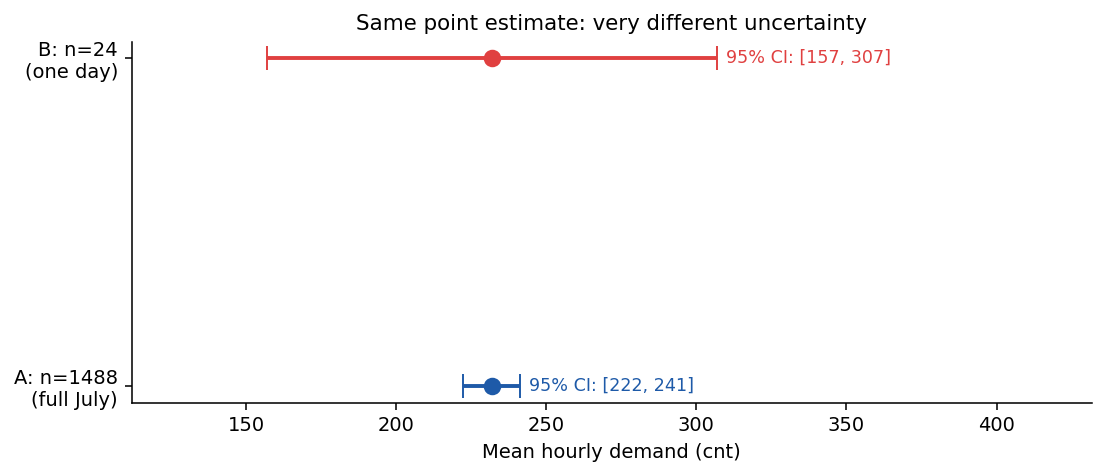

In [4]:
# Same point estimate, very different standard errors
xbar = cnt_july.mean()
s    = cnt_july.std(ddof=1)
n_A  = len(cnt_july)  # full July
n_B  = 24             # one day

se_A = s / np.sqrt(n_A)
se_B = s / np.sqrt(n_B)

print(f'July mean demand: {xbar:.1f} rentals/hour')
print(f'July std:         {s:.1f}')
print(f'Scenario A (n={n_A}): SE = {se_A:.1f}')
print(f'Scenario B (n={n_B}):  SE = {se_B:.1f}')
print(f'Uncertainty ratio B/A: {se_B/se_A:.1f}x larger')

fig, ax = plt.subplots(figsize=(8, 3.5))
for i, (label, se, color) in enumerate([
    (f'A: n={n_A} (full July)', se_A, BLUE),
    (f'B: n={n_B} (one day)',   se_B, RED)
]):
    lo, hi = xbar - 1.96*se, xbar + 1.96*se
    ax.errorbar(xbar, i, xerr=1.96*se, fmt='o', color=color,
                capsize=6, markersize=8, linewidth=2)
    ax.text(hi + 3, i, f'95% CI: [{lo:.0f}, {hi:.0f}]',
            va='center', fontsize=9, color=color)
ax.set_yticks([0, 1])
ax.set_yticklabels([f'A: n={n_A}\n(full July)', f'B: n={n_B}\n(one day)'])
ax.set_xlabel('Mean hourly demand (cnt)')
ax.set_title('Same point estimate: very different uncertainty')
ax.set_xlim(xbar - 120, xbar + 200)
plt.tight_layout()
plt.show()

---
## Block 2. Frequentist vs. Bayesian Probability

The same axioms (Kolmogorov, 1933) support two very different interpretations:

| Aspect | Frequentist | Bayesian |
|---|---|---|
| What probability means | Long-run relative frequency of an event | Degree of belief about an uncertain quantity |
| Parameters $\theta$ | Fixed, unknown constants | Random variables with distributions |
| Data | Random (drawn from a distribution) | Observed and fixed once seen |
| Central tool | Sampling distribution of $\hat{\theta}$ | Posterior $P(\theta \mid \text{data})$ |
| Interval | Confidence interval | Credible interval |
| Prior information | Not formally incorporated | Encoded in $P(\theta)$ |
| Repeated-experiment guarantee | Yes | Not the goal |

**Neither is "right."** They answer different questions. In practice, most applied work uses both: frequentist tools for quick inference, Bayesian tools when priors are available and decisions require full distributions.

> **Common confusion.** "There is a 90% chance the true mean is between 260 and 290." Is this frequentist or Bayesian? A Bayesian credible interval makes this statement directly. A frequentist confidence interval does **not**: the parameter is fixed, so the probability is either 0 or 1. The correct frequentist statement is: "90% of such intervals, constructed from repeated samples, will contain the true mean."

---
## Block 3. Confidence Intervals

### Definition

A $(1-\alpha) \times 100\%$ **confidence interval** for parameter $\theta$ is a random interval $[L(D), U(D)]$ such that:
$$P_\theta(L(D) \leq \theta \leq U(D)) = 1 - \alpha \quad \text{for all } \theta$$

The probability is over repeated samples $D$. The **interval is random** (it changes with each dataset); the **parameter is fixed**.

|$\,$ | Correct | Wrong |
|---|---|---|
| **Interpretation** | "If I repeat this experiment many times, $(1-\alpha)\times 100\%$ of such intervals will contain $\theta$." | "There is a $(1-\alpha)\times 100\%$ probability that $\theta$ is in this specific interval." |

### CI for a mean

With known variance $\sigma^2$: $\bar{x} \pm z_{\alpha/2} \cdot \sigma/\sqrt{n}$

With unknown variance (realistic): $\bar{x} \pm t_{n-1,\alpha/2} \cdot s/\sqrt{n}$

For large $n$, $t_{n-1} \approx N(0,1)$. For small $n$, the $t$-interval is wider, reflecting extra uncertainty in estimating $\sigma$.


### Confidence interval for a mean

With **known variance** $\sigma^2$: $\bar{x} \pm z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}$

where $z_{1-\alpha/2}$ is the $(1-\alpha/2)$-quantile of the standard normal distribution: $Z \sim N(0,1),\qquad P\left(Z \leq z_{1-\alpha/2}\right)=1-\frac{\alpha}{2}.$

For a $95\%$ confidence interval, $\alpha=0.05$, and therefore: $z_{1-\alpha/2}=z_{0.975}\approx 1.96.$

Thus, the interval becomes: $\bar{x} \pm 1.96\frac{\sigma}{\sqrt{n}}.$

With **unknown variance**, which is the usual practical case: $\bar{x} \pm t_{n-1,\,1-\alpha/2}\frac{s}{\sqrt{n}}$

where $s$ is the sample standard deviation and $t_{n-1,\,1-\alpha/2}$ is the $(1-\alpha/2)$-quantile of a Student-$t$ distribution with $n-1$ degrees of freedom.

As $n$ increases, the Student-$t$ distribution approaches the standard normal distribution: $t_{n-1} \to N(0,1)$ as $n \to \infty$.

For small $n$, the Student-$t$ distribution has heavier tails, resulting in a wider confidence interval. This reflects the additional uncertainty introduced by estimating $\sigma$ using $s$.


### Visualizing the frequentist interpretation

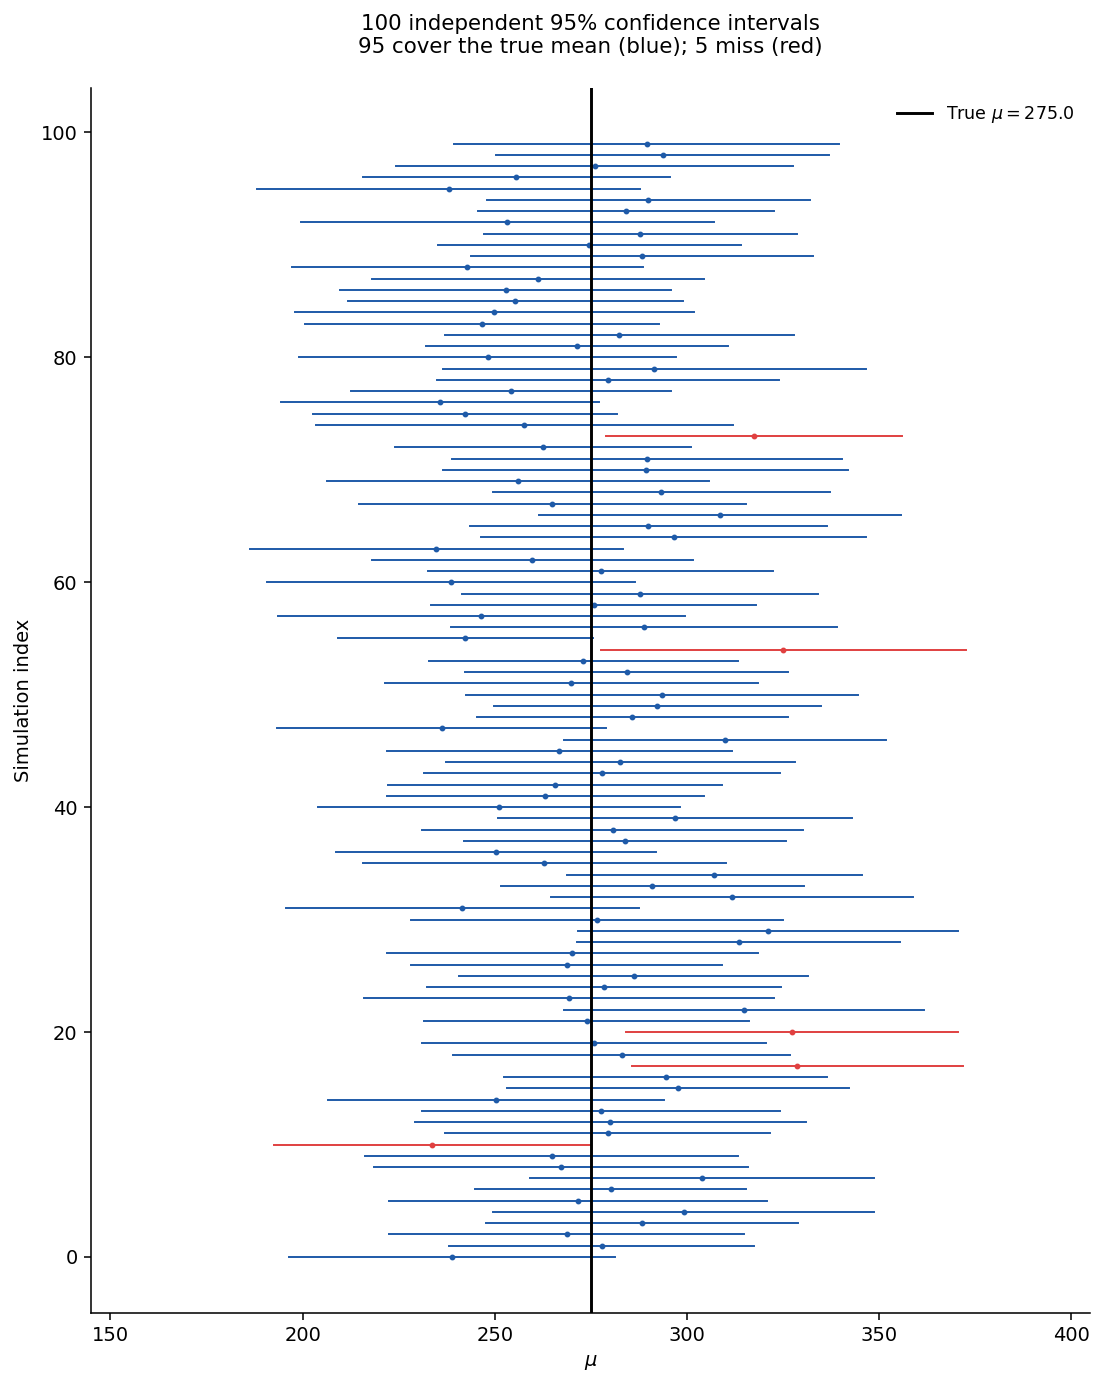

In [5]:
# NOTE: The number of intervals that miss the true value is random (depends on the seed).
# With SEED=42 and 100 simulations, we get exactly 5 misses — consistent with the 95% guarantee
# (we expect 5 on average). Re-running with a different seed will give a different count.

# --- 100 confidence intervals from 100 independent samples ---
# The frequentist guarantee: ~95% of them contain the true parameter.

mu_true    = 275.0
sigma_true = 160.0
n_sim_ci   = 50
n_cis      = 100

fig, ax = plt.subplots(figsize=(8, 10))
n_miss = 0
for i in range(n_cis):
    samp   = rng.normal(mu_true, sigma_true, n_sim_ci)
    xbar_i = samp.mean()
    se_i   = samp.std(ddof=1) / np.sqrt(n_sim_ci)
    t_c    = t_dist.ppf(0.975, df=n_sim_ci-1)
    lo_i, hi_i = xbar_i - t_c*se_i, xbar_i + t_c*se_i
    covers = lo_i <= mu_true <= hi_i
    color  = BLUE if covers else RED
    ax.plot([lo_i, hi_i], [i, i], color=color, linewidth=1)
    ax.plot(xbar_i, i, 'o', color=color, markersize=2)
    if not covers:
        n_miss += 1

ax.axvline(mu_true, color='black', linewidth=1.5, linestyle='-',
           label=f'True $\\mu = {mu_true}$')
ax.set_xlabel('$\\mu$')
ax.set_ylabel('Simulation index')
ax.set_title(f'100 independent 95% confidence intervals\n'
             f'{n_cis - n_miss} cover the true mean (blue); {n_miss} miss (red)\n')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(mu_true - 130, mu_true + 130)
plt.tight_layout()
plt.show()

In [6]:
# --- Exercise: 95% CI for mean hourly demand (overall vs. July) ---

def t_ci(data, alpha=0.05):
    n = len(data)
    xbar = data.mean()
    se   = data.std(ddof=1) / np.sqrt(n)
    t_c  = t_dist.ppf(1 - alpha/2, df=n-1)
    return xbar, xbar - t_c*se, xbar + t_c*se, se

xb_all, lo_all, hi_all, se_all = t_ci(bikes['cnt'].values)
xb_jul, lo_jul, hi_jul, se_jul = t_ci(cnt_july)

print(f"{'Dataset':<12}  {'Mean':>8}  {'95% CI':>22}  {'Width':>8}")
print('-' * 58)
print(f"{'Overall':<12}  {xb_all:>8.1f}  [{lo_all:>8.1f}, {hi_all:>8.1f}]  {hi_all-lo_all:>8.1f}")
print(f"{'July only':<12}  {xb_jul:>8.1f}  [{lo_jul:>8.1f}, {hi_jul:>8.1f}]  {hi_jul-lo_jul:>8.1f}")
print(f'\nJuly CI is {(hi_jul-lo_jul)/(hi_all-lo_all):.1f}x wider than overall '
      f'because n_July ({len(cnt_july)}) < n_overall ({len(bikes)})')

Dataset           Mean                  95% CI     Width
----------------------------------------------------------
Overall          189.5  [   186.8,    192.2]       5.4
July only        231.8  [   222.3,    241.4]      19.1

July CI is 3.5x wider than overall because n_July (1488) < n_overall (17379)


### Confidence intervals and prediction intervals in linear regression

Consider the linear regression model:

$$
\mathbf{y} = X\boldsymbol{\beta} + \boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon} \sim N(\mathbf{0}, \sigma^2 I).
$$

Under these assumptions:

$$
\hat{\boldsymbol{\beta}}
\sim
N
\left(
\boldsymbol{\beta},
\,
\sigma^2(X^\top X)^{-1}
\right).
$$

### Confidence interval for a regression coefficient

A $95\%$ confidence interval for coefficient $\beta_j$ is:

$$
\hat{\beta}_j
\pm
t_{n-p-1,\,0.975}
\cdot
\hat{\sigma}
\sqrt{
\left[(X^\top X)^{-1}\right]_{jj}
}.
$$

Here, $n$ is the number of observations, $p$ is the number of predictors, and $\hat{\sigma}$ is the estimated residual standard deviation.

The interval becomes wider when:

- the data are noisier;
- the sample size is smaller;
- predictor $X_j$ is strongly correlated with other predictors.

The last case is called **multicollinearity**.

For example, `temp` and `atemp` contain similar information. If both are included in the model, it becomes difficult to separate their individual effects. Their confidence intervals may become wider even if the model predictions remain stable.

> **Key insight:** multicollinearity increases uncertainty in individual coefficients, but it does not necessarily increase prediction error.

### Confidence interval for the mean response

For a new input $x_0$, the predicted mean response is:

$$
\hat{y}(x_0) = x_0^\top \hat{\boldsymbol{\beta}}.
$$

A confidence interval for the mean response estimates the uncertainty in the regression line:

$$
\hat{y}(x_0)
\pm
t_{n-p-1,\,0.975}
\cdot
\hat{\sigma}
\sqrt{
x_0^\top (X^\top X)^{-1}x_0
}.
$$

It answers:

> What is the average expected bike demand for these conditions?

In the figure, this is the narrow blue region.

### Prediction interval for a new observation

A prediction interval estimates the range for one future observation:

$$
\hat{y}(x_0)
\pm
t_{n-p-1,\,0.975}
\cdot
\hat{\sigma}
\sqrt{
1 + x_0^\top (X^\top X)^{-1}x_0
}.
$$

It answers:

> What bike demand might we observe in one specific future case?

The prediction interval is wider because it includes both uncertainty in the regression line and the natural variability of individual observations.

In the figure, this is the wider red region.

> **Key distinction:** the confidence interval describes uncertainty in the estimated mean response, whereas the prediction interval describes uncertainty in a new individual observation.

In [7]:
# --- CI for regression coefficients: with and without collinear atemp ---

X1 = sm.add_constant(bikes[['temp', 'hum', 'windspeed']])
X2 = sm.add_constant(bikes[['temp', 'atemp', 'hum', 'windspeed']])

ols1 = sm.OLS(bikes['cnt'], X1).fit()
ols2 = sm.OLS(bikes['cnt'], X2).fit()

print('=== Model 1: cnt ~ temp + hum + windspeed ===')
print(ols1.summary2().tables[1].to_string())
print('\n=== Model 2: cnt ~ temp + atemp + hum + windspeed ===')
print(ols2.summary2().tables[1].to_string())
print('\n→ Adding atemp (highly collinear with temp) dramatically widens the CI for temp.')
print('  The p-value for temp increases, but this does NOT mean temperature is irrelevant!')

=== Model 1: cnt ~ temp + hum + windspeed ===
                Coef.   Std.Err.          t          P>|t|      [0.025      0.975]
const      175.810001   6.186965  28.416195  1.169536e-173  163.682928  187.937074
temp       362.534418   6.204933  58.426806   0.000000e+00  350.372125  374.696710
hum       -273.465110   6.469479 -42.270039   0.000000e+00 -286.145938 -260.784281
windspeed   26.319828  10.180111   2.585417   9.734208e-03    6.365787   46.273869

=== Model 2: cnt ~ temp + atemp + hum + windspeed ===
                Coef.   Std.Err.          t          P>|t|      [0.025      0.975]
const      161.806902   6.505687  24.871609  3.330828e-134  149.055102  174.558703
temp        85.576497  40.751436   2.099963   3.574650e-02    5.699585  165.453409
atemp      314.342929  45.714387   6.876236   6.354541e-12  224.738135  403.947723
hum       -275.180313   6.465693 -42.560068   0.000000e+00 -287.853720 -262.506905
windspeed   42.979255  10.451271   4.112347   3.934586e-05   22.49371

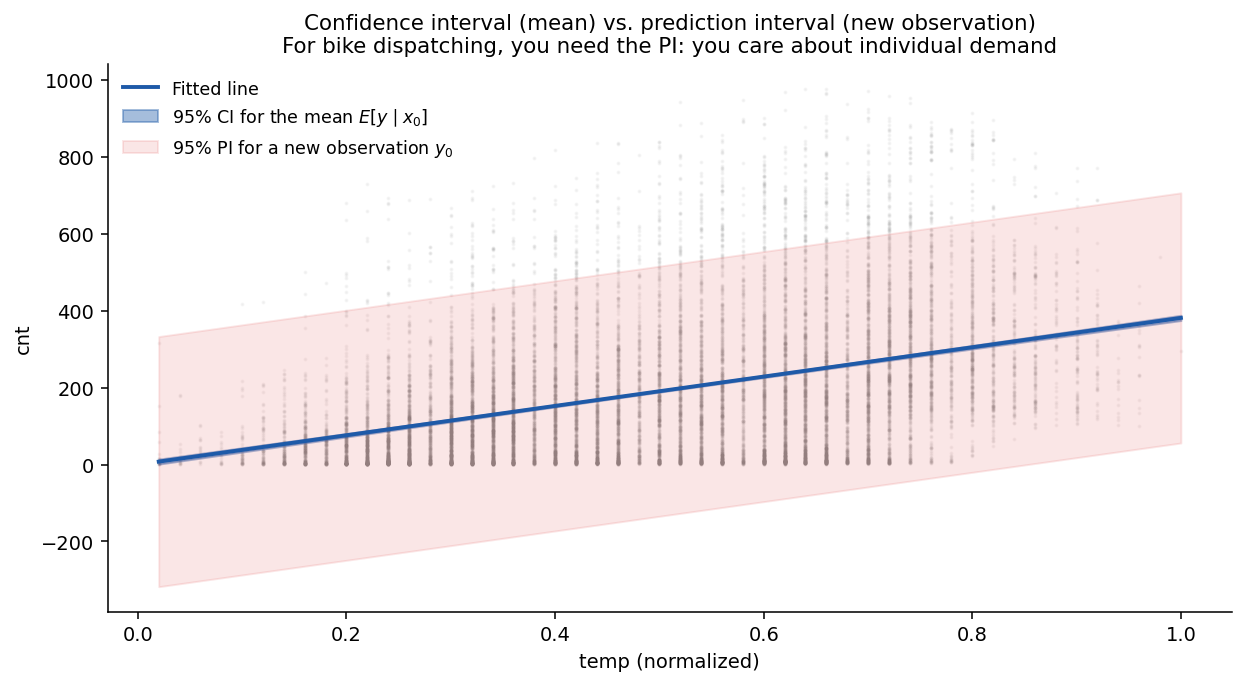

PI formula: hat_y ± t * hat_sigma * sqrt(1 + x0^T (X^T X)^{-1} x0)
CI formula: hat_y ± t * hat_sigma * sqrt(    x0^T (X^T X)^{-1} x0)
The extra 1 under the sqrt adds the irreducible noise sigma^2.


In [25]:
# --- Prediction interval vs. confidence interval for the mean ---
# CI for the mean: uncertainty about where the regression LINE is
# PI for a new obs: adds irreducible noise sigma^2 -> always wider

X_temp = sm.add_constant(bikes['temp'])
ols_temp = sm.OLS(bikes['cnt'], X_temp).fit()

temp_grid = np.linspace(bikes['temp'].min(), bikes['temp'].max(), 200)
X_grid    = sm.add_constant(temp_grid)
pred      = ols_temp.get_prediction(X_grid)
cf        = pred.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(bikes['temp'], bikes['cnt'], s=1, alpha=0.07, color=GRAY, zorder=1)
ax.plot(temp_grid, cf['mean'], color=BLUE, linewidth=2, label='Fitted line', zorder=3)
ax.fill_between(temp_grid, cf['mean_ci_lower'], cf['mean_ci_upper'],
                alpha=0.4, color=BLUE,
                label='95% CI for the mean $E[y \\mid x_0]$', zorder=2)
ax.fill_between(temp_grid, cf['obs_ci_lower'], cf['obs_ci_upper'],
                alpha=0.13, color=RED,
                label='95% PI for a new observation $y_0$', zorder=2)
ax.set_xlabel('temp (normalized)')
ax.set_ylabel('cnt')
ax.set_title('Confidence interval (mean) vs. prediction interval (new observation)\n'
             'For bike dispatching, you need the PI: you care about individual demand')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print('PI formula: hat_y ± t * hat_sigma * sqrt(1 + x0^T (X^T X)^{-1} x0)')
print('CI formula: hat_y ± t * hat_sigma * sqrt(    x0^T (X^T X)^{-1} x0)')
print('The extra 1 under the sqrt adds the irreducible noise sigma^2.')

**This distinction matters operationally.** A dashboard that shows the CI for the mean (narrow band) instead of the PI (wide band) will systematically understate uncertainty, leading to under-provisioning of bikes at peak hours.

---
## Block 4. Credible Intervals

### Definition

A $(1-\alpha) \times 100 \%$ **credible interval** is a region $C$ of the posterior such that:
$$P(\theta \in C \mid \text{data}) = 1 - \alpha$$

The probability is now **directly about $\theta$**: the statement most people actually are looking for when they say "I'm 95% sure the true mean is in here."

|$\,$ | CI (frequentist) | Credible interval (Bayesian) |
|---|---|---|
| Probability statement | Over repeated experiments | Over possible parameter values |
| Requires a prior? | No | Yes |
| Directly says $P(\theta \in C \mid D)$? | No | Yes |
| As $n \to \infty$ | Agree | Agree |

### Conjugate normal model

If $x_1, \ldots, x_n \sim N(\mu, \sigma^2)$ with $\sigma^2$ known and prior $\mu \sim N(\mu_0, \tau_0^2)$, the posterior is:
$$\mu \mid x_1, \ldots, x_n \sim N(\mu_n, \tau_n^2)$$

where the posterior mean is a **precision-weighted average** of the prior mean and the data mean:
$$\mu_n = \frac{\frac{1}{\tau_0^2}\mu_0 + \frac{n}{\sigma^2}\bar{x}}{\frac{1}{\tau_0^2} + \frac{n}{\sigma^2}}, \qquad \frac{1}{\tau_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2}$$

As $n \to \infty$: $\mu_n \to \bar{x}$ and $\tau_n^2 \to 0$ The data overwhelm the prior.

The posterior mean is a compromise between what we believed before seeing the data $(μ_0)$ and what the data suggest $(\bar{x})$. The more precise a source of information is, the more influence it has on the posterior estimate.

> Recall that precision is defined as the inverse of variance:
> $$\text{precision=1/variance}$$

Data: n=1488, xbar=231.8, sigma=187.5
Frequentist 95% CI: [222.3, 241.3]

Weak prior: $\mu_0=250, \tau_0=50$
  Posterior mean: 232.0, 95% credible interval: [222.5, 241.5]

Strong prior: $\mu_0=200, \tau_0=10$
  Posterior mean: 225.7, 95% credible interval: [217.2, 234.3]



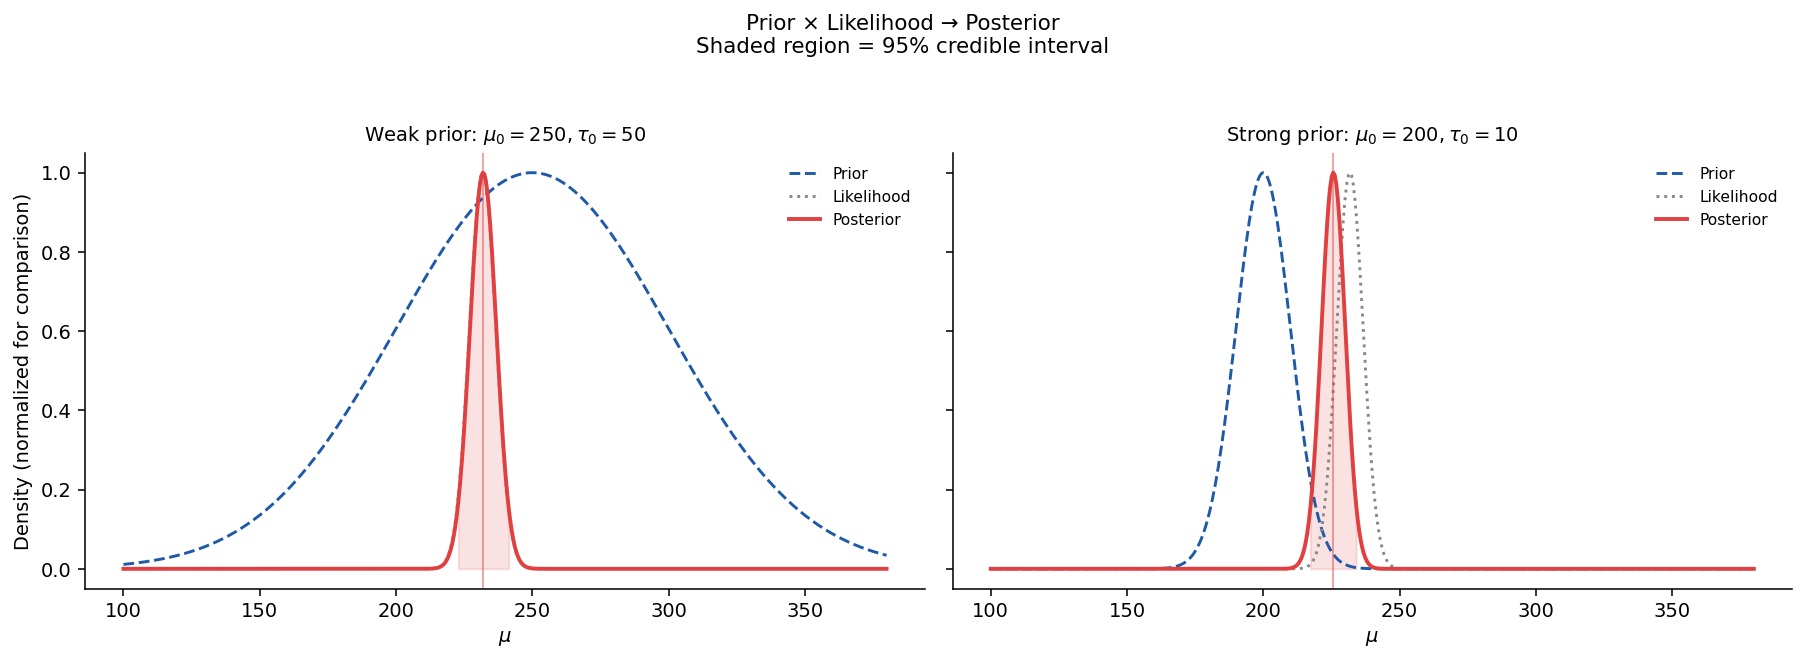

In [9]:
# --- Conjugate normal update: weak vs. strong prior ---

def conjugate_update(mu0, tau0, sigma, xbar, n):
    prec_prior = 1 / tau0**2
    prec_data  = n / sigma**2
    tau_n = 1 / np.sqrt(prec_prior + prec_data)
    mu_n  = (prec_prior * mu0 + prec_data * xbar) / (prec_prior + prec_data)
    return mu_n, tau_n

sigma_known = cnt_july.std(ddof=1)  # use sample std as plug-in
xbar_july   = cnt_july.mean()
n_july      = len(cnt_july)
se_july     = sigma_known / np.sqrt(n_july)

priors = [
    (250, 50,  'Weak prior: $\\mu_0=250, \\tau_0=50$'),
    (200, 10,  'Strong prior: $\\mu_0=200, \\tau_0=10$'),
]

print(f'Data: n={n_july}, xbar={xbar_july:.1f}, sigma={sigma_known:.1f}')
print(f'Frequentist 95% CI: [{xbar_july - 1.96*se_july:.1f}, {xbar_july + 1.96*se_july:.1f}]\n')

x_range = np.linspace(100, 380, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (mu0, tau0, title) in zip(axes, priors):
    mu_n, tau_n = conjugate_update(mu0, tau0, sigma_known, xbar_july, n_july)

    prior_pdf = sp_norm.pdf(x_range, mu0, tau0)
    like_pdf  = sp_norm.pdf(x_range, xbar_july, se_july)
    post_pdf  = sp_norm.pdf(x_range, mu_n,  tau_n)

    # Normalize for visual comparison
    for pdf in [prior_pdf, like_pdf, post_pdf]:
        pdf /= pdf.max()

    ax.plot(x_range, prior_pdf, color=BLUE,   linewidth=1.5, linestyle='--', label='Prior')
    ax.plot(x_range, like_pdf,  color=GRAY,   linewidth=1.5, linestyle=':',  label='Likelihood')
    ax.plot(x_range, post_pdf,  color=RED,    linewidth=2.0,                 label='Posterior')
    ci_lo, ci_hi = mu_n - 1.96*tau_n, mu_n + 1.96*tau_n
    ax.fill_between(x_range, 0, post_pdf,
                    where=(x_range >= ci_lo) & (x_range <= ci_hi),
                    alpha=0.15, color=RED)
    ax.axvline(mu_n, color=RED, linewidth=0.8, alpha=0.6)
    ax.axvline(xbar_july, color=GRAY, linewidth=0.8, alpha=0.6, linestyle=':')
    # Annotate key values in the plot
    ax.text(0.97, 0.97,
            f'Prior mean: {mu0:.0f}\nLikelihood mean: {xbar_july:.1f}\nPosterior mean: {mu_n:.1f}\n95% CI: [{ci_lo:.1f}, {ci_hi:.1f}]',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$\\mu$')
    ax.legend(frameon=False, fontsize=8)
    print(f'{title}\n  Posterior mean: {mu_n:.1f}, 95% credible interval: [{ci_lo:.1f}, {ci_hi:.1f}]\n')

axes[0].set_ylabel('Density (normalized for comparison)')
fig.suptitle('Prior × Likelihood → Posterior\nShaded region = 95% credible interval', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

**What to observe:**
- **Weak prior (left):** The prior is broad and contributes little. The posterior is nearly identical to the likelihood, and the 95% credible interval nearly matches the frequentist CI.
- **Strong prior (right):** The prior ($\mu_0 = 200$, $\tau_0 = 10$) pulls the posterior away from the data mean. With enough data, even a wrong prior eventually loses, but here $n = 1488$ is insufficient to fully overcome a precise prior that is $\sim 30$ units off.

> **Why do the prior peak positions look different across subplots?** The curves are normalized to the same peak height (max = 1) for visual comparison, not to integrate to 1. This means the horizontal positions of the peaks are correct (they reflect the actual prior means), but the relative heights do not represent true probability masses. In both panels, the prior mean is exactly as specified ($\mu_0 = 250$ and $\mu_0 = 200$). The text box in each panel reports the exact numerical values of the likelihood mean, posterior mean, and 95% credible interval for reference.

---
## Block 5. Bootstrapping

### The idea (Efron, 1979)

The sampling distribution of $\hat{\theta}$ can be approximated by **resampling from the data itself**:

1. From $D = \{x_1, \ldots, x_n\}$, draw $B$ bootstrap samples $D^{*1}, \ldots, D^{*B}$, each of size $n$ **with replacement**.
2. Compute $\hat{\theta}^{*b} = \hat{\theta}(D^{*b})$ for each $b$.
3. The empirical distribution of $\{\hat{\theta}^{*1}, \ldots, \hat{\theta}^{*B}\}$ approximates the sampling distribution of $\hat{\theta}$.

**Why it works.** The empirical distribution $\hat{F}_n$ converges to the true $F$. Resampling from $\hat{F}_n$ mimics sampling from $F$.

> **A useful fact:** each bootstrap sample draws $n$ points with replacement from $n$ observations. The fraction of distinct points in one bootstrap sample is approximately $1 - 1/e \approx 63.2\%$. The remaining $\sim 36.8\%$ of the original data are "out of bag" and were never selected. This is the basis of the out-of-bag error in random forests.


- **Bootstrap Percentile:** $[\hat{\theta}^*_{\alpha/2},\, \hat{\theta}^*_{1-\alpha/2}]$

Bootstrap (B=2000) for July cnt:
  Mean:   231.9,  95% boot CI: [222.8, 241.6]
           (t-CI for comparison:  [222.3, 241.3])  <- nearly identical
  Median: 202.5,  95% boot CI: [189.0, 214.0]
  Why bootstrap for median? No simple closed-form sampling distribution.


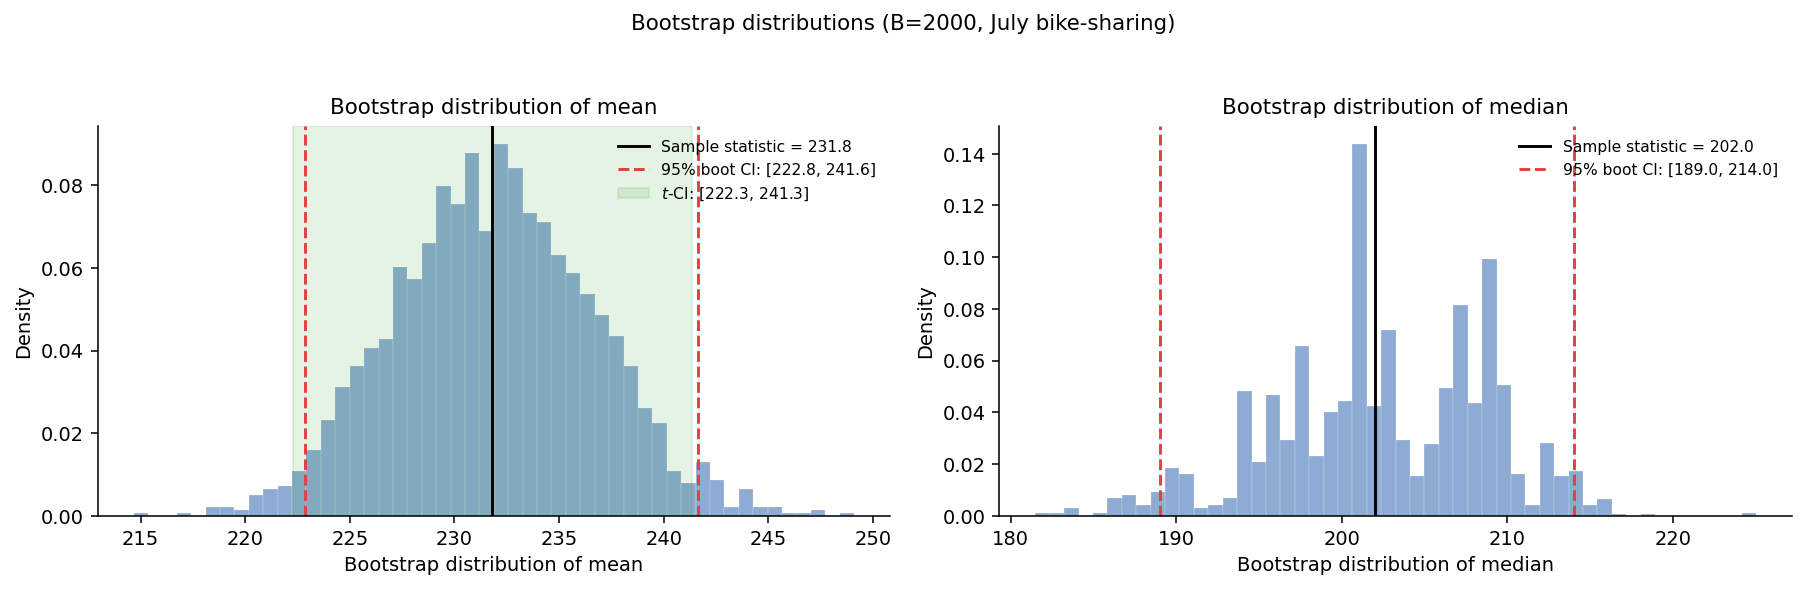

In [10]:
# --- Bootstrap the mean and median of July cnt ---
# Compare bootstrap CI for the mean to the t-interval.

B = 2000
n_j = len(cnt_july)
boot_means   = np.array([cnt_july[rng.randint(0, n_j, n_j)].mean()   for _ in range(B)])
boot_medians = np.array([np.median(cnt_july[rng.randint(0, n_j, n_j)]) for _ in range(B)])

ci_boot_mean   = np.percentile(boot_means,   [2.5, 97.5])
ci_boot_median = np.percentile(boot_medians, [2.5, 97.5])
ci_t_mean      = (xbar_july - 1.96*se_july, xbar_july + 1.96*se_july)

print(f'Bootstrap (B={B}) for July cnt:')
print(f'  Mean:   {boot_means.mean():.1f},  95% boot CI: [{ci_boot_mean[0]:.1f}, {ci_boot_mean[1]:.1f}]')
print(f'           (t-CI for comparison:  [{ci_t_mean[0]:.1f}, {ci_t_mean[1]:.1f}])  <- nearly identical')
print(f'  Median: {boot_medians.mean():.1f},  95% boot CI: [{ci_boot_median[0]:.1f}, {ci_boot_median[1]:.1f}]')
print(f'  Why bootstrap for median? No simple closed-form sampling distribution.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, ci, label, ref, ref_lo, ref_hi, extra_label, extra_lo, extra_hi in [
    (axes[0], boot_means,   ci_boot_mean,   'Bootstrap distribution of mean',
     xbar_july, ci_t_mean[0], ci_t_mean[1], '$t$-CI', ci_t_mean[0], ci_t_mean[1]),
    (axes[1], boot_medians, ci_boot_median, 'Bootstrap distribution of median',
     np.median(cnt_july), None, None, None, None, None),
]:
    ax.hist(data, bins=50, color=BLUE, alpha=0.5, edgecolor='white', linewidth=0.2, density=True)
    ax.axvline(ref, color='black', linewidth=1.5, label=f'Sample statistic = {ref:.1f}')
    ax.axvline(ci[0], color=RED, linewidth=1.5, linestyle='--')
    ax.axvline(ci[1], color=RED, linewidth=1.5, linestyle='--',
               label=f'95% boot CI: [{ci[0]:.1f}, {ci[1]:.1f}]')
    if extra_lo is not None:
        ax.axvspan(extra_lo, extra_hi, alpha=0.12, color=GREEN,
                   label=f'{extra_label}: [{extra_lo:.1f}, {extra_hi:.1f}]')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(f'Bootstrap distributions (B={B}, July bike-sharing)', fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

**Observation.** The bootstrap CI for the mean closely matches the $t$-interval (as expected for large $n$). For the **median**, check the plot directly: the CI width depends on the actual data distribution.

> **Common misconception:** the median is not always estimated more precisely than the mean. For a Normal distribution, the asymptotic variance of the sample median is $\pi/2 \approx 1.57$ times larger than the variance of the sample mean, so the median CI is *wider*. For heavily right-skewed distributions (like bike demand, where a few extreme hours inflate the mean), the median can be estimated with similar or even lower variance. The bootstrap lets you measure this empirically without relying on asymptotic formulas.

---

## Block 6. Hypothesis Testing

### The testing framework

A hypothesis test asks: **is the observed pattern consistent with a specific null world?**

| Term | Definition | Example |
|---|---|---|
| **Null $H_0$** | A precise claim; usually "no effect" | $H_0: \mu_{\text{Adelie}} = \mu_{\text{Chinstrap}}$ |
| **Alternative $H_1$** | The complement | $H_1: \mu_{\text{Adelie}} \neq \mu_{\text{Chinstrap}}$ |
| **Test statistic $T$** | A function of data measuring evidence against $H_0$ | Welch's $t$ |
| **$p$-value** | $P(\|T\| \geq \|t_{\text{obs}}\| \mid H_0)$  probability of observing data this extreme if $H_0$ were true | $\,$ |

**Welch's $t$-test** (default for two groups, does not assume equal variances):
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}$$

### What the $p$-value is and is NOT

| $\,$ | Correct | Wrong |
|---|---|---|
| **$p$-value is...** | $P(\text{data this extreme} \mid H_0)$ | $P(H_0 \text{ is true} \mid \text{data})$ that requires a prior |
| **A small $p$ means...** | The data are unlikely under $H_0$ | That the effect is large or important |
| **Statistical significance** | The threshold $\alpha$ controls Type I error rate | Equals practical significance |

### Effect size: what the $p$-value does not tell you

The $p$-value conflates signal strength and sample size. **Cohen's $d$** isolates the signal:
$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_p} \quad \text{where } s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

Rough guidelines: $d = 0.2$ (small), $d = 0.5$ (medium), $d = 0.8$ (large). A large $n$ can make a tiny $d$ "significant"; always report both.

Adelie:    n=151, mean=38.79 mm, std=2.66
Chinstrap: n=68, mean=48.83 mm, std=3.34
Difference (Chinstrap - Adelie): 10.04 mm
t = 21.86, p = 2.90e-41
95% CI for difference: [9.13, 10.95] mm
Cohen's d = 3.48 → LARGE (≥ 0.8)


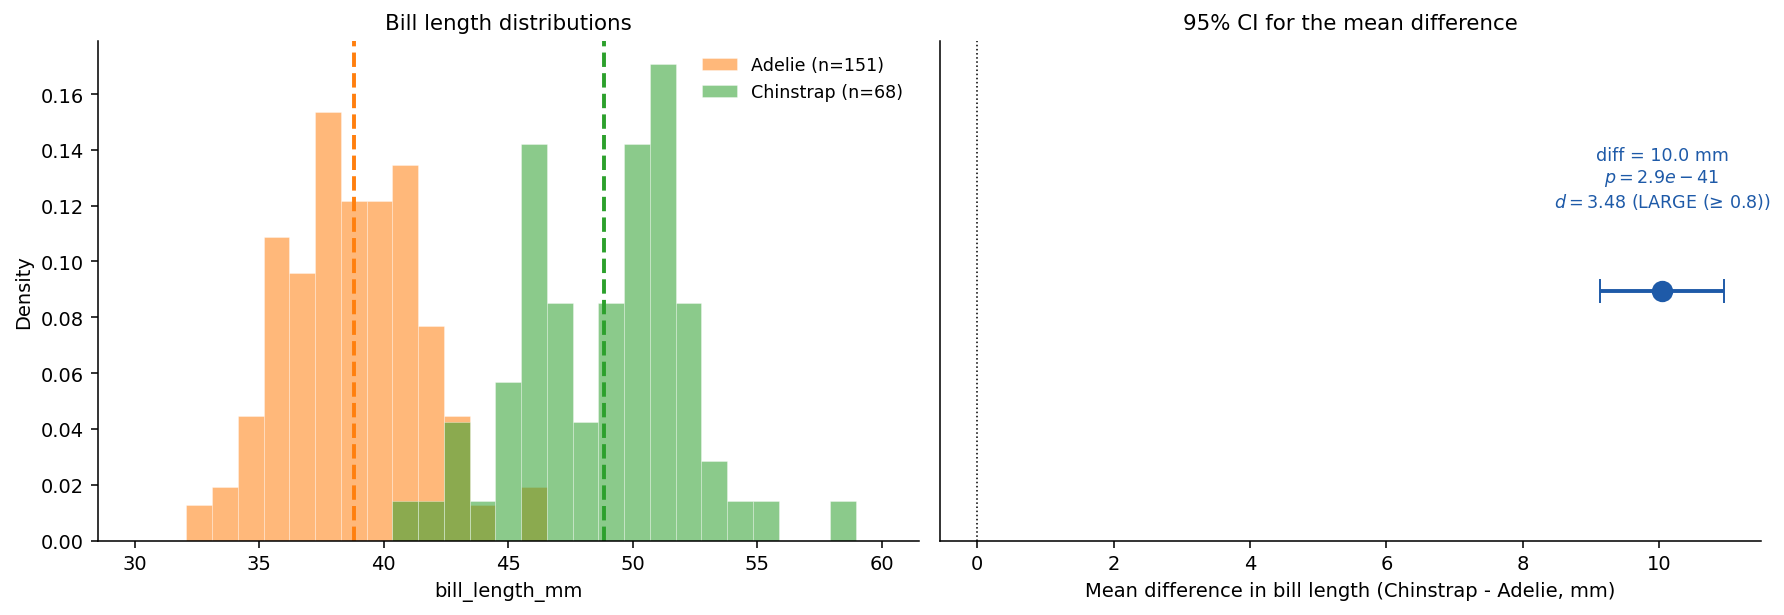

In [8]:
# --- t-test: Adelie vs. Chinstrap bill length ---

t_stat, p_val = stats.ttest_ind(chinstrap, adelie, equal_var=False)
diff = chinstrap.mean() - adelie.mean()
se_diff = np.sqrt(chinstrap.var(ddof=1)/len(chinstrap) + adelie.var(ddof=1)/len(adelie))
nu = se_diff**4 / (
    (chinstrap.var(ddof=1)/len(chinstrap))**2/(len(chinstrap)-1) +
    (adelie.var(ddof=1)/len(adelie))**2/(len(adelie)-1)
)
ci_diff = (diff - t_dist.ppf(0.975, nu)*se_diff, diff + t_dist.ppf(0.975, nu)*se_diff)

# Cohen's d
n1, n2 = len(adelie), len(chinstrap)
sp = np.sqrt(((n1-1)*adelie.var(ddof=1) + (n2-1)*chinstrap.var(ddof=1)) / (n1+n2-2))
d_full = diff / sp
size_label = 'LARGE (≥ 0.8)' if d_full >= 0.8 else ('MEDIUM (≥ 0.5)' if d_full >= 0.5 else 'SMALL')

print(f'Adelie:    n={n1}, mean={adelie.mean():.2f} mm, std={adelie.std(ddof=1):.2f}')
print(f'Chinstrap: n={n2}, mean={chinstrap.mean():.2f} mm, std={chinstrap.std(ddof=1):.2f}')
print(f'Difference (Chinstrap - Adelie): {diff:.2f} mm')
print(f't = {t_stat:.2f}, p = {p_val:.2e}')
print(f'95% CI for difference: [{ci_diff[0]:.2f}, {ci_diff[1]:.2f}] mm')
print(f"Cohen's d = {d_full:.2f} → {size_label}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bill length distributions
bins = np.linspace(30, 60, 30)
axes[0].hist(adelie,    bins=bins, alpha=0.55, color=ORANGE, edgecolor='white',
             linewidth=0.3, density=True, label=f'Adelie (n={n1})')
axes[0].hist(chinstrap, bins=bins, alpha=0.55, color=GREEN,  edgecolor='white',
             linewidth=0.3, density=True, label=f'Chinstrap (n={n2})')
axes[0].axvline(adelie.mean(),    color=ORANGE, linewidth=2, linestyle='--')
axes[0].axvline(chinstrap.mean(), color=GREEN,  linewidth=2, linestyle='--')
axes[0].set_xlabel('bill_length_mm')
axes[0].set_ylabel('Density')
axes[0].set_title('Bill length distributions')
axes[0].legend(frameon=False, fontsize=9)

# Right: CI for the difference
axes[1].errorbar(diff, 0, xerr=[[diff - ci_diff[0]], [ci_diff[1] - diff]],
                 fmt='o', color=BLUE, capsize=6, markersize=10, linewidth=2)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].text(diff, 0.2,
             f'diff = {diff:.1f} mm\n$p = {p_val:.1e}$\n$d = {d_full:.2f}$ ({size_label})',
             ha='center', fontsize=9, color=BLUE)
axes[1].set_xlabel('Mean difference in bill length (Chinstrap - Adelie, mm)')
axes[1].set_yticks([])
axes[1].set_title('95% CI for the mean difference')
axes[1].set_ylim(-0.6, 0.6)

plt.tight_layout()
plt.show()

Full sample (n=151 Adelie, 68 Chinstrap):
  Cohen's d = 3.48,  p = 2.90e-41
Subsamples (n=10 per species, 200 replications):
  Mean Cohen's d = 3.44  (stable | population property)
  Mean p-value   = 0.0000  (much larger | depends heavily on n)
  Fraction with p < 0.05: 100%


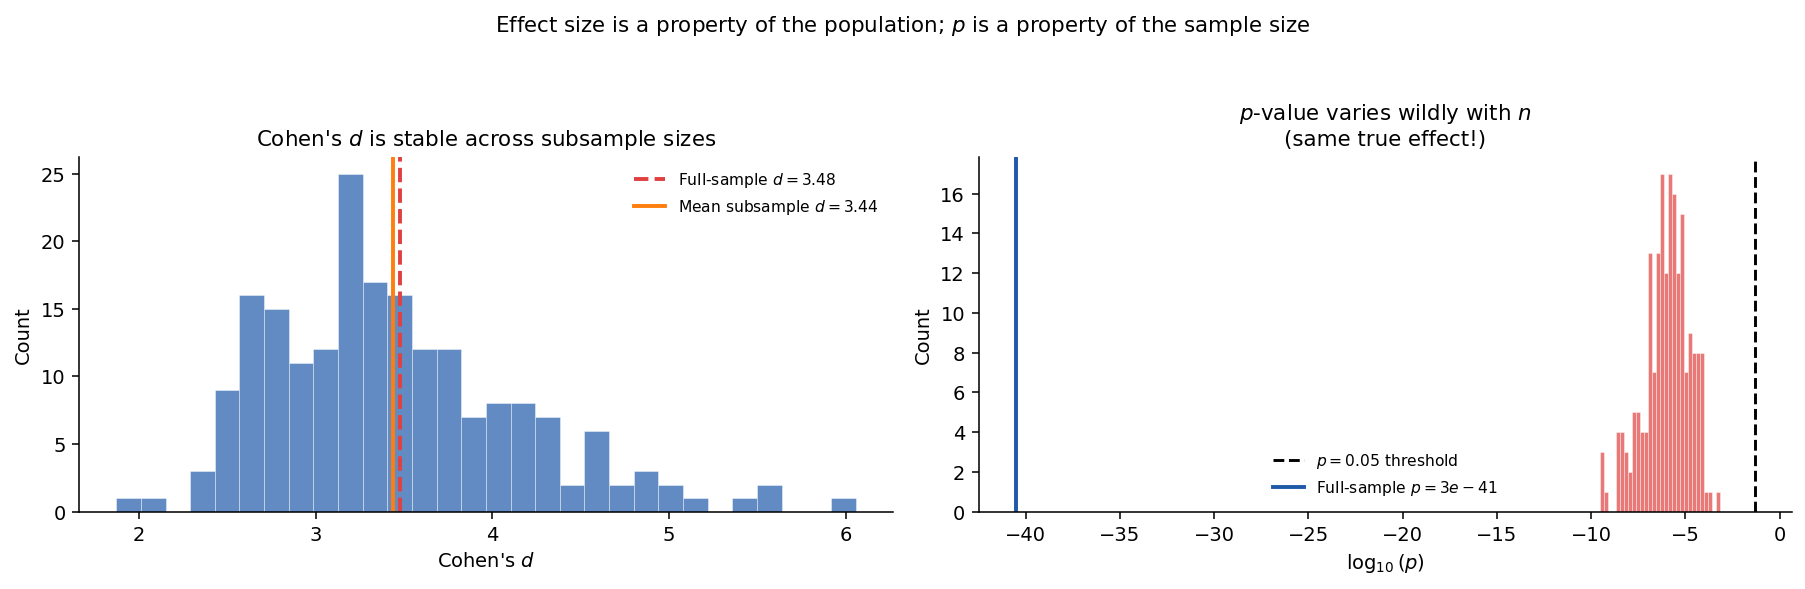

In [9]:
# --- Cohen's d is stable with n; p-value is not ---
# Repeat the t-test on small subsamples of n=10 per species.

d_subs, p_subs = [], []
for i in range(200):
    a_sub = rng.choice(adelie,    10, replace=False)
    c_sub = rng.choice(chinstrap, 10, replace=False)
    _, p_sub = stats.ttest_ind(c_sub, a_sub, equal_var=False)
    sp_sub = np.sqrt((9*a_sub.var(ddof=1) + 9*c_sub.var(ddof=1)) / 18)
    d_sub  = (c_sub.mean() - a_sub.mean()) / sp_sub
    d_subs.append(d_sub)
    p_subs.append(p_sub)

print(f'Full sample (n={n1} Adelie, {n2} Chinstrap):')
print(f"  Cohen's d = {d_full:.2f},  p = {p_val:.2e}")
print(f'Subsamples (n=10 per species, 200 replications):')
print(f"  Mean Cohen's d = {np.mean(d_subs):.2f}  (stable | population property)")
print(f'  Mean p-value   = {np.mean(p_subs):.4f}  (much larger | depends heavily on n)')
print(f'  Fraction with p < 0.05: {np.mean(np.array(p_subs) < 0.05):.0%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(d_subs, bins=30, color=BLUE, alpha=0.7, edgecolor='white', linewidth=0.3)
axes[0].axvline(d_full, color=RED, linewidth=2, linestyle='--',
                label=f'Full-sample $d = {d_full:.2f}$')
axes[0].axvline(np.mean(d_subs), color=ORANGE, linewidth=2,
                label=f'Mean subsample $d = {np.mean(d_subs):.2f}$')
axes[0].set_xlabel("Cohen's $d$")
axes[0].set_ylabel('Count')
axes[0].set_title("Cohen's $d$ is stable across subsample sizes")
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(np.log10(np.array(p_subs) + 1e-15), bins=30, color=RED, alpha=0.7,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(np.log10(0.05), color='black', linewidth=1.5, linestyle='--',
                label='$p = 0.05$ threshold')
axes[1].axvline(np.log10(p_val), color=BLUE, linewidth=2,
                label=f'Full-sample $p = {p_val:.0e}$')
axes[1].set_xlabel('$\\log_{10}(p)$')
axes[1].set_ylabel('Count')
axes[1].set_title('$p$-value varies wildly with $n$\n(same true effect!)')
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle('Effect size is a property of the population; $p$ is a property of the sample size',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()

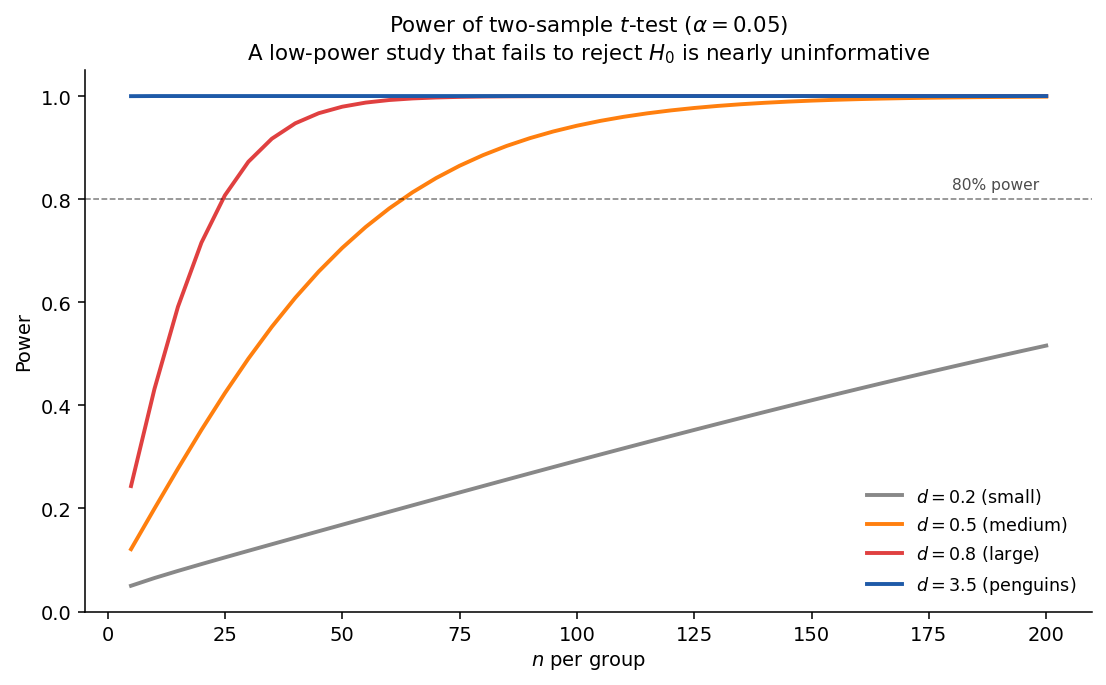

Approximate n needed for 80% power:
  d=0.2 (small)                 : n per group = >200
  d=0.5 (medium)                : n per group = 65
  d=0.8 (large)                 : n per group = 25
  d=3.5 (penguins)              : n per group = 5


In [13]:
# --- Power curves for the two-sample t-test ---
# Power = P(reject H0 | H1 true). Increases with n, d, and alpha.

ns_power = np.arange(5, 201, 5)
d_vals   = [0.2, 0.5, 0.8, d_full]
d_labels = ['$d=0.2$ (small)', '$d=0.5$ (medium)', '$d=0.8$ (large)',
            f'$d={d_full:.1f}$ (penguins)']
colors_d = [GRAY, ORANGE, RED, BLUE]

fig, ax = plt.subplots(figsize=(8, 5))
for d_val, label, color in zip(d_vals, d_labels, colors_d):
    power = sp_norm.cdf(d_val * np.sqrt(ns_power / 2) - sp_norm.ppf(0.975))
    ax.plot(ns_power, power, linewidth=2, label=label, color=color)

ax.axhline(0.8, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(180, 0.82, '80% power', fontsize=8, color='black', alpha=0.7)
ax.set_xlabel('$n$ per group')
ax.set_ylabel('Power')
ax.set_title('Power of two-sample $t$-test ($\\alpha = 0.05$)\n'
             'A low-power study that fails to reject $H_0$ is nearly uninformative')
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('Approximate n needed for 80% power:')
for d_val, label in zip(d_vals, d_labels):
    n_needed = next((n for n in ns_power
                     if sp_norm.cdf(d_val*np.sqrt(n/2) - sp_norm.ppf(0.975)) >= 0.8), '>200')
    clean_label = label.replace("$","").replace("\\","")
    print(f'  {clean_label:<30}: n per group = {n_needed}')

### Limitations of NHST (null hypothesis significance testing)

| Problem | Description |
|---|---|
| **The null is always false** | No two population means are *exactly* equal. With enough data, any test will reject. The real question is "how large is the effect?", not "is there an effect?" |
| **$p$-hacking** | Selective reporting, data-dependent stopping, undisclosed multiple testing. All inflate false positives |
| **Replication crisis** | The Open Science Collaboration (2015) replicated 100 psychology studies; only 36% replicated at $p < 0.05$ |
| **File-drawer problem** | Significant results are published; null results are not, biasing the literature |

**Modern alternatives:** pre-registration, reporting effect sizes and intervals as primary output, equivalence testing, Bayesian model comparison.

---

## Block 7. Aleatoric vs. Epistemic Uncertainty

There are two fundamentally different reasons why we are uncertain:

| $\,$| **Aleatoric** (from *alea*, dice) | **Epistemic / Model error** (from *episteme*, knowledge) |
|---|---|---|
| Source | Irreducible randomness in the data-generating process | Limited knowledge: finite data, model misspecification |
| Example | Bike demand at 5 PM is inherently variable; weather, events, day of week all interact | If we had 10× more training data, our demand forecasts would be tighter |
| Reducible? | **No**, no model can beat $\sigma^2$ | **Yes** more data or better models reduce it |
| In the bias-variance formula | $\sigma^2$ | Bias² (model error) + Variance (estimation error) |

$$\text{EPE} = \sigma^2(x_0) + \text{Bias}^2 + \text{Var}$$

where $\sigma^2(x_0)$ is **aleatoric uncertainty** (irreducible), $\text{Bias}^2$ is **model error** (reducible by using a better model), and $\text{Var}$ is **estimation error** (reducible with more data).

**Practical importance.** If a model is very confident on a data point far from any training example (epistemic uncertainty should be high), it is poorly calibrated. Epistemic uncertainty should signal "I have not seen data like this; be careful."

**Heteroscedasticity** is aleatoric uncertainty that depends on the input: $\text{Var}(\epsilon \mid x) = \sigma^2(x)$. Standard OLS assumes $\sigma^2(x) = \sigma^2$ (constant). When this is violated, OLS gives constant-width prediction intervals that are too narrow in some regions and too wide in others.

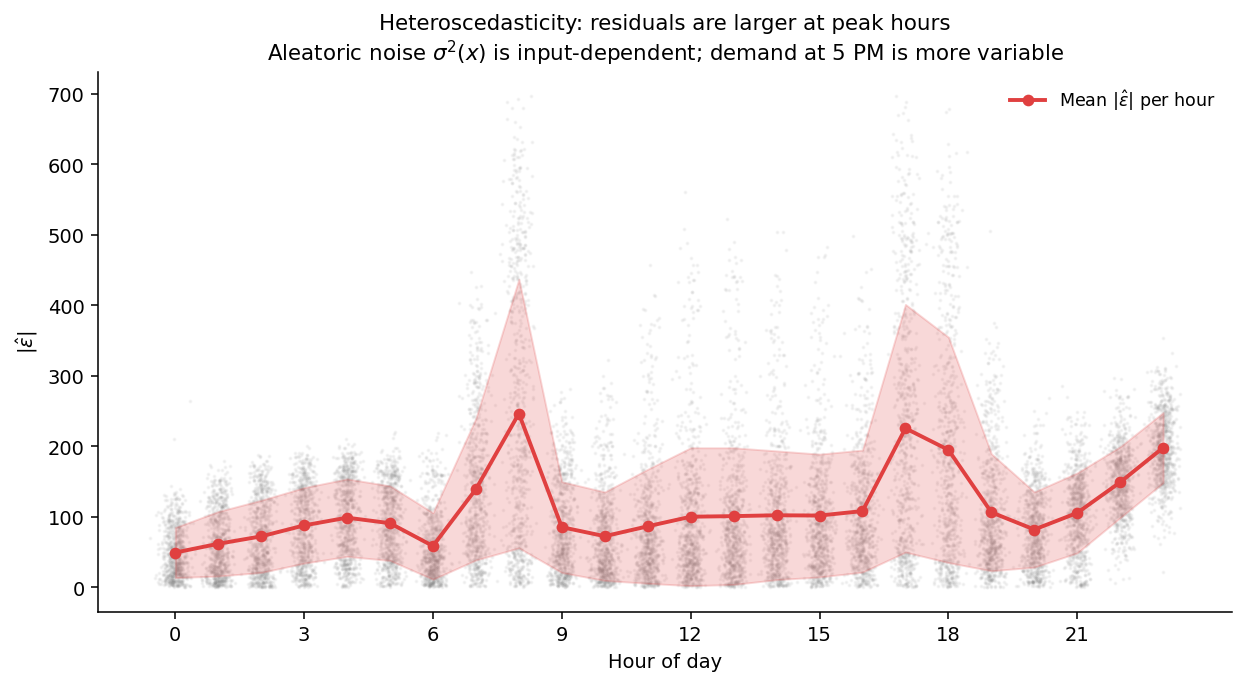

In [20]:
# --- Exercise: heteroscedastic residuals (aleatoric uncertainty depends on hour) ---

X_het = bikes[['temp', 'hr']].values
y_het = bikes['cnt'].values
lr_het = LinearRegression().fit(X_het, y_het)
resid  = y_het - lr_het.predict(X_het)

abs_resid_by_hr = pd.DataFrame({'hr': bikes['hr'], 'abs_resid': np.abs(resid)})
hr_stats = abs_resid_by_hr.groupby('hr')['abs_resid'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(bikes['hr'] + rng.normal(0, 0.15, len(resid)), np.abs(resid),
           s=1, alpha=0.08, color=GRAY)
ax.plot(hr_stats.index, hr_stats['mean'], 'o-', color=RED, markersize=5,
        linewidth=2, label='Mean $|\\hat{\\epsilon}|$ per hour')
ax.fill_between(hr_stats.index,
                hr_stats['mean'] - hr_stats['std'],
                hr_stats['mean'] + hr_stats['std'],
                alpha=0.2, color=RED)
ax.set_xlabel('Hour of day')
ax.set_ylabel('$|\\hat{\\epsilon}|$')
ax.set_title('Heteroscedasticity: residuals are larger at peak hours\n'
             'Aleatoric noise $\\sigma^2(x)$ is input-dependent; demand at 5 PM is more variable')
ax.legend(frameon=False, fontsize=9)
ax.set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

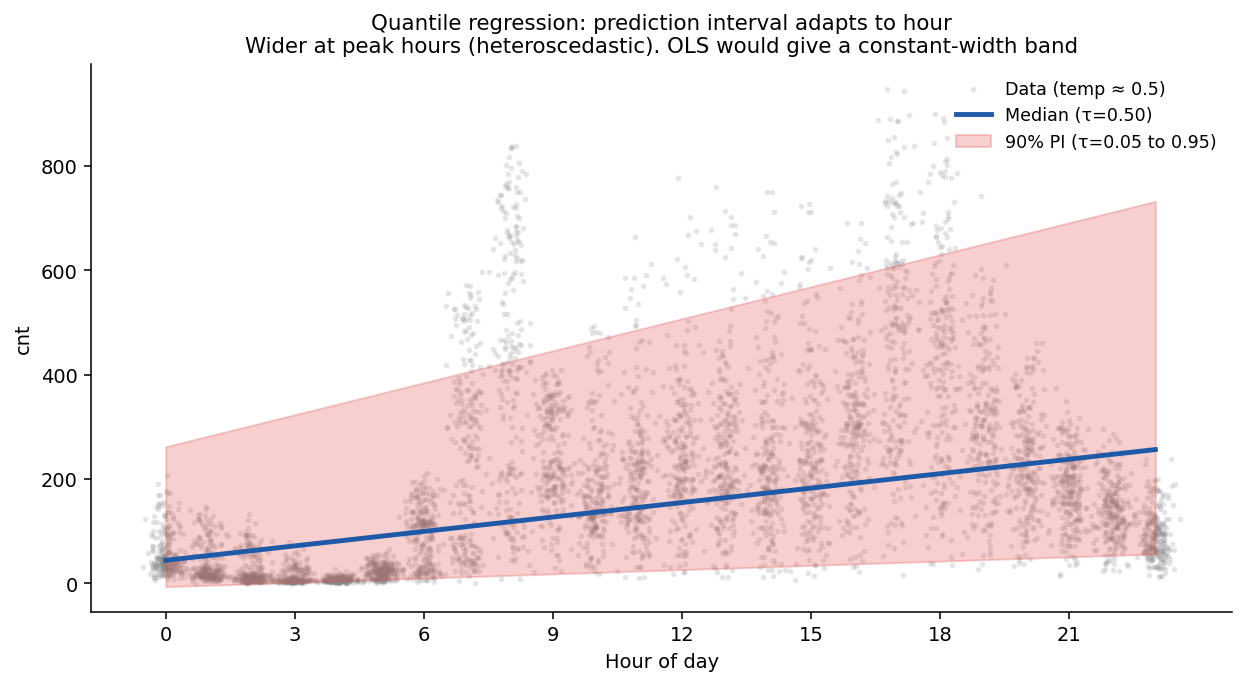

In [19]:
# --- Quantile regression: prediction interval that adapts to input-dependent noise ---
# Fit at tau=0.05 and tau=0.95 to get a 90% empirical prediction interval.

# Subsample for speed
n_sub = 5000
idx_sub = rng.choice(len(y_het), n_sub, replace=False)
X_sub, y_sub = X_het[idx_sub], y_het[idx_sub]

qr_lo  = QuantileRegressor(quantile=0.05, alpha=0.0, solver='highs').fit(X_sub, y_sub)
qr_hi  = QuantileRegressor(quantile=0.95, alpha=0.0, solver='highs').fit(X_sub, y_sub)
qr_med = QuantileRegressor(quantile=0.50, alpha=0.0, solver='highs').fit(X_sub, y_sub)

hrs      = np.arange(24)
X_qr_plt = np.column_stack([np.full(24, 0.5), hrs])  # temp=0.5 (moderate)

fig, ax = plt.subplots(figsize=(9, 5))
mask_temp = (bikes['temp'] >= 0.4) & (bikes['temp'] <= 0.6)
ax.scatter(bikes.loc[mask_temp, 'hr'] + rng.normal(0, 0.2, mask_temp.sum()),
           bikes.loc[mask_temp, 'cnt'],
           s=4, alpha=0.15, color=GRAY, label='Data (temp ≈ 0.5)')
ax.plot(hrs, qr_med.predict(X_qr_plt), color=BLUE, linewidth=2.5, label='Median (τ=0.50)')
ax.fill_between(hrs, qr_lo.predict(X_qr_plt), qr_hi.predict(X_qr_plt),
                alpha=0.25, color=RED, label='90% PI (τ=0.05 to 0.95)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('cnt')
ax.set_title('Quantile regression: prediction interval adapts to hour\n'
             'Wider at peak hours (heteroscedastic). OLS would give a constant-width band')
ax.legend(frameon=False, fontsize=9)
ax.set_xticks(range(0, 24, 3))
plt.tight_layout()
plt.show()

**Why do the 90% bounds grow roughly linearly with hour?** Quantile regression, like OLS, fits a *linear* function of the input features. With `hr` as a feature, the predicted quantiles are linear in `hr`. This is why the bands widen (or narrow) in straight lines rather than following the curved shape of the data density.

**How to model this differently:** If the true uncertainty structure is non-linear in `hr` (as suggested by the data, demand is low at night, peaks in the morning and evening), consider:

- **Cyclic/harmonic features:** replace `hr` with `sin(2*pi*hr/24)` and `cos(2*pi*hr/24)` to capture the daily cycle.
- **Polynomial or spline features:** add `hr^2` or spline basis functions to allow curved bands.
- **Generalized Additive Models (GAMs):** fit a smooth non-parametric function of `hr` for each quantile.

---
## Block 8. Bayesian Updating and Decision-Making

### Bayes' theorem: the update rule

$$P(\theta \mid D) = \frac{P(D \mid \theta) \cdot P(\theta)}{P(D)}$$

| Term | Name | Meaning |
|---|---|---|
| $P(\theta)$ | **Prior** | What you believe before seeing data |
| $P(D \mid \theta)$ | **Likelihood** | How probable the data are under each $\theta$ |
| $P(D)$ | **Evidence** | Normalizing constant $\int P(D \mid \theta) P(\theta) \, d\theta$ |
| $P(\theta \mid D)$ | **Posterior** | Your updated belief after seeing data |

**Key property: sequential updating.** Today's posterior is tomorrow's prior. If data arrive one day at a time $D_1, D_2, \ldots$:
$$P(\theta \mid D_1, D_2) = \frac{P(D_2 \mid \theta) \cdot P(\theta \mid D_1)}{P(D_2 \mid D_1)}$$

No need to reprocess all past data. The posterior summarizes everything learned so far.

### Decision-making under uncertainty

Define **actions** $a \in A$, **states** $\theta \in \Theta$, and a **loss** $L(a, \theta)$. The **Bayesian optimal action** minimizes expected loss under the posterior:
$$a^* = \arg\min_a \int L(a, \theta) \cdot P(\theta \mid D) \, d\theta$$

**Bike example.** Understocking costs $c_u$ per unmet rental; overstocking costs $c_o$ per idle bike:
$$a^* = \arg\min_a \left[c_u \int_a^\infty (d-a)P(d \mid D)\,dd + c_o \int_0^a (a-d)P(d \mid D)\,dd\right]$$

For asymmetric costs ($c_u \neq c_o$), the optimal $a$ is the $c_u/(c_u + c_o)$ **quantile** of the predictive distribution, not the mean.

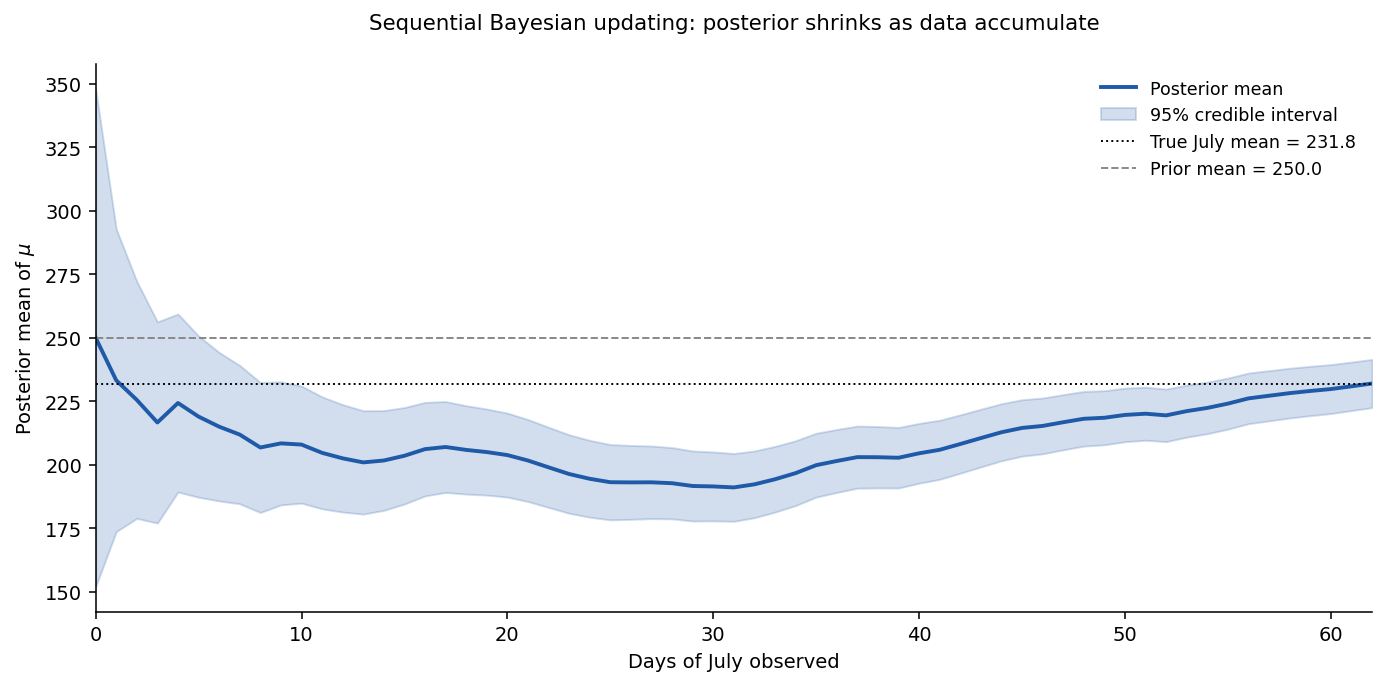

After day 1:  posterior mean = 233.2, CI width = 119.1
After day 62: posterior mean = 232.0, CI width = 19.0
CI shrinks by 6.3× over the month.


In [18]:
# --- Sequential Bayesian updating: one day at a time ---

july_sorted = july.sort_values(['yr', 'mnth', 'dteday', 'hr']).reset_index(drop=True)
n_days = len(july_sorted) // 24

def conjugate_update(mu0, tau0, sigma, xbar, n):
    prec_prior = 1 / tau0**2
    prec_data  = n  / sigma**2
    tau_n = 1 / np.sqrt(prec_prior + prec_data)
    mu_n  = (prec_prior * mu0 + prec_data * xbar) / (prec_prior + prec_data)
    return mu_n, tau_n

mu0, tau0 = 250.0, 50.0
sigma_k = cnt_july.std(ddof=1)

days, post_means, post_lo, post_hi = [0], [mu0], [mu0 - 1.96*tau0], [mu0 + 1.96*tau0]
cur_mu, cur_tau = mu0, tau0

for day in range(n_days):
    day_data = july_sorted.iloc[day*24:(day+1)*24]['cnt'].values
    cur_mu, cur_tau = conjugate_update(cur_mu, cur_tau, sigma_k, day_data.mean(), len(day_data))
    days.append(day + 1)
    post_means.append(cur_mu)
    post_lo.append(cur_mu - 1.96*cur_tau)
    post_hi.append(cur_mu + 1.96*cur_tau)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(days, post_means, color=BLUE, linewidth=2, label='Posterior mean')
ax.fill_between(days, post_lo, post_hi, alpha=0.2, color=BLUE, label='95% credible interval')
ax.axhline(cnt_july.mean(), color='black', linewidth=1, linestyle=':',
           label=f'True July mean = {cnt_july.mean():.1f}')
ax.axhline(mu0, color=GRAY, linewidth=1, linestyle='--',
           label=f'Prior mean = {mu0}')
ax.set_xlabel('Days of July observed')
ax.set_ylabel('Posterior mean of $\\mu$')
ax.set_title('Sequential Bayesian updating: posterior shrinks as data accumulate\n(prior mean = 250; true mean = 231.8 — early CIs may not cover due to prior pull)')
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, n_days)
plt.tight_layout()
plt.show()

print(f'After day 1:  posterior mean = {post_means[1]:.1f}, CI width = {post_hi[1]-post_lo[1]:.1f}')
print(f'After day {n_days}: posterior mean = {post_means[-1]:.1f}, CI width = {post_hi[-1]-post_lo[-1]:.1f}')
print(f'CI shrinks by {(post_hi[1]-post_lo[1])/(post_hi[-1]-post_lo[-1]):.1f}× over the month.')

> **Does the 95% CI always cover the true mean?** Not necessarily, especially early in the sequence. The prior is centered at $\mu_0 = 250$, while the true July mean is approximately 231.8. Early on, the posterior is dominated by the prior and is pulled toward 250. As the credible interval narrows (more data observed), it may briefly exclude the true mean before the data overwhelm the prior and the posterior converges to the correct value. This is expected behavior under a mis-specified prior. It illustrates **prior sensitivity**: a strong prior that is far from the truth will cause the early posterior to miss the true parameter. With a better-calibrated prior (e.g., $\mu_0 = 230$), this would not occur. In practice, prior sensitivity analysis (trying multiple priors) is good Bayesian workflow.

Cost structure: c_u = 3 (understock), c_o = 1 (overstock)
Optimal quantile: c_u / (c_u + c_o) = 0.75
Predictive distribution: N(232.0, 187.5^2)
Stock at the mean:     232 bikes
Stock at optimal q:    358 bikes
Difference:            +126 bikes vs. naive forecast


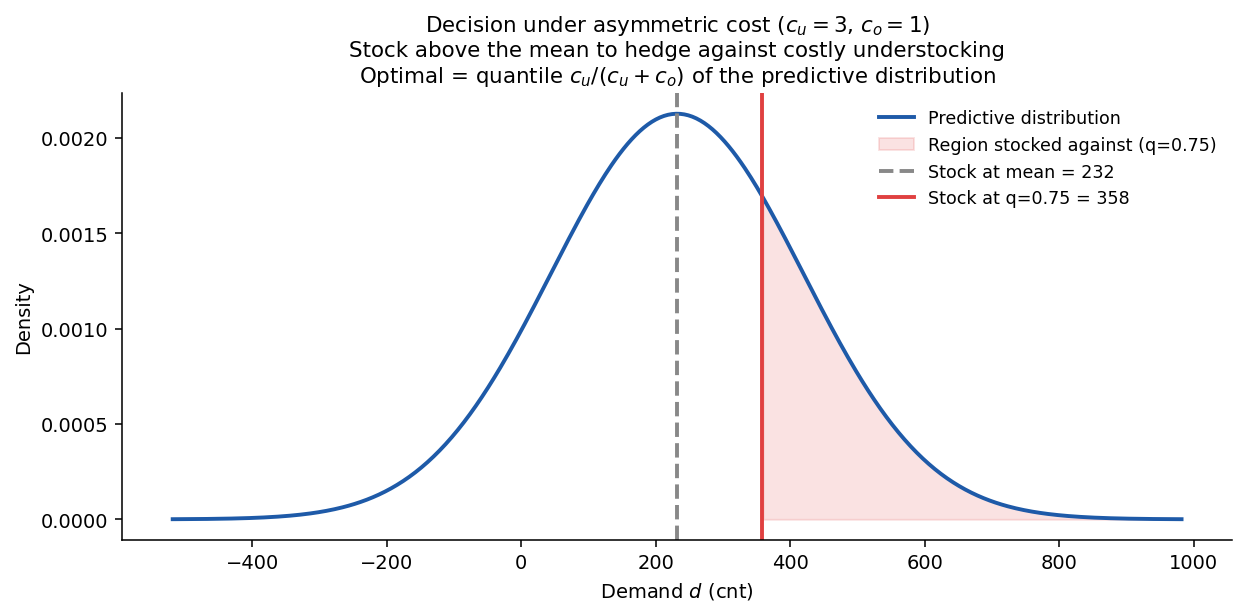

In [17]:
# --- Decision under asymmetric cost ---
# If c_u > c_o (understocking is more costly), stock above the mean.
# Optimal: stock at the c_u/(c_u + c_o) quantile of the predictive distribution.

c_u = 3   # cost per unmet rental (understocking)
c_o = 1   # cost per idle bike (overstocking)
optimal_q = c_u / (c_u + c_o)  # = 0.75

# Predictive distribution: posterior for mu + observation noise
final_mu  = post_means[-1]
final_tau = (post_hi[-1] - post_lo[-1]) / (2 * 1.96)
pred_std  = np.sqrt(final_tau**2 + sigma_k**2)  # parameter uncertainty + noise

a_mean     = final_mu
a_optimal  = stats.norm.ppf(optimal_q, loc=final_mu, scale=pred_std)

print(f'Cost structure: c_u = {c_u} (understock), c_o = {c_o} (overstock)')
print(f'Optimal quantile: c_u / (c_u + c_o) = {optimal_q:.2f}')
print(f'Predictive distribution: N({final_mu:.1f}, {pred_std:.1f}^2)')
print(f'Stock at the mean:     {a_mean:.0f} bikes')
print(f'Stock at optimal q:    {a_optimal:.0f} bikes')
print(f'Difference:            +{a_optimal - a_mean:.0f} bikes vs. naive forecast')

x_pred = np.linspace(final_mu - 4*pred_std, final_mu + 4*pred_std, 500)
y_pred = stats.norm.pdf(x_pred, final_mu, pred_std)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_pred, y_pred, color=BLUE, linewidth=2, label='Predictive distribution')
ax.fill_between(x_pred, 0, y_pred, where=x_pred >= a_optimal,
                alpha=0.15, color=RED, label=f'Region stocked against (q={optimal_q:.2f})')
ax.axvline(a_mean,    color=GRAY, linewidth=2, linestyle='--',
           label=f'Stock at mean = {a_mean:.0f}')
ax.axvline(a_optimal, color=RED,  linewidth=2,
           label=f'Stock at q={optimal_q:.2f} = {a_optimal:.0f}')
ax.set_xlabel('Demand $d$ (cnt)')
ax.set_ylabel('Density')
ax.set_title(f'Decision under asymmetric cost ($c_u = {c_u}$, $c_o = {c_o}$)\n'
             f'Stock above the mean to hedge against costly understocking\n'
             f'Optimal = quantile $c_u/(c_u+c_o)$ of the predictive distribution')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Why stock above the mean?** When $c_u > c_o$, the cost of running out of bikes is higher than the cost of having idle bikes. The symmetric decision (stock at the mean) minimizes expected squared error, not expected cost. The asymmetric optimal policy shifts the decision toward the higher quantile to buffer against costly shortages.

> **General principle.** If $c_u / (c_u + c_o) > 0.5$ (understocking is costlier), stock above the mean. If $c_u / (c_u + c_o) < 0.5$ (overstocking is costlier), stock below the mean. If $c_u = c_o$, stock at the median.

---
## Summary

| Block | Key idea | Practical takeaway |
|---|---|---|
| **1. Why UQ** | Point estimates without intervals are incomplete | Always report effect sizes with intervals |
| **2. Freq. vs. Bayes** | Same axioms, different interpretations of probability | Know which framework you're using and what it allows you to say |
| **3. Confidence intervals** | The interval is random, not the parameter | A 95% CI is a statement about the procedure, not about this specific interval |
| **4. Credible intervals** | $P(\theta \in C \mid \text{data}) = 0.95$, direct statement about the parameter | Large $n$ makes them nearly identical to frequentist CIs (data overwhelm prior) |
| **5. Bootstrap** | Approximate any sampling distribution by resampling | Works for any statistic; compare to analytical CIs when available |
| **6. Hypothesis testing** | $p$-value $\neq$ $P(H_0)$; always report effect size | Statistical significance $\neq$ practical significance; a large $n$ makes tiny effects "significant" |
| **7. Aleat. vs. epist.** | $\sigma^2$ is irreducible; Bias² + Var is reducible | Calibrated uncertainty should be large far from training data (epistemic) |
| **8. Bayes + decisions** | Prior × Likelihood $\propto$ Posterior | Asymmetric costs → stock at a quantile, not the mean |


### References

- Efron, B. (1979). Bootstrap Methods: Another Look at the Jackknife. *Annals of Statistics*, 7(1).
- Gelman, A., et al. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.
- Wasserstein, R. L., and Lazar, N. A. (2016). The ASA Statement on $p$-Values. *The American Statistician*, 70(2).
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences*. Lawrence Erlbaum.
- Lakshminarayanan, B., Pritzel, A., and Blundell, C. (2017). Deep Ensembles. *NeurIPS*.
- Vovk, V., Gammerman, A., and Shafer, G. (2005). *Algorithmic Learning in a Random World*. Springer.
- Berger, J. O. (1985). *Statistical Decision Theory and Bayesian Analysis*. Springer.
- Open Science Collaboration (2015). Estimating the Reproducibility of Psychological Science. *Science*, 349(6251).